

When people think about evolution, they often think about **natural selection**.

Natural selection explains how advantageous genetic variants become more common because they improve survival or reproduction.

However, natural selection is not the only force driving evolution.

Even in the complete absence of selection, allele frequencies can change over time simply because populations are finite.

This phenomenon is called **genetic drift**.

Genetic drift is one of the most fundamental concepts in population genetics because it explains:

- Random changes in allele frequencies
- Loss of genetic diversity
- Founder effects
- Population bottlenecks
- Neutral evolution
- Fixation and extinction of alleles

Understanding drift is essential for modern genomics, GWAS, evolutionary biology, conservation genetics, and statistical genetics.


In this tutorial we will study:

1. What genetic drift is
2. Why fixation occurs
3. The Wright-Fisher model
4. Important theoretical results
5. Simulation of allele-frequency trajectories
6. Verification of classical population genetics theorems

### Learning Objectives

By the end of this tutorial you should be able to:

- Explain genetic drift intuitively
- Derive the Wright-Fisher model
- Understand fixation and extinction
- Simulate neutral evolution
- Interpret allele frequency trajectories
- Understand why small populations drift faster than large populations
- Connect drift to modern genomic studies

### Prerequisites

This tutorial assumes familiarity with:

- Basic probability
- Binomial distributions
- Python programming
- Elementary genetics

No prior knowledge of population genetics is required.


### What is an Allele?

A gene can exist in different versions called alleles.

For example:

| Gene | Alleles |
|--------|---------|
| Eye color gene | Blue, Brown |
| SNP rs12345 | A, G |

Suppose a locus contains two alleles:

$$
A
$$

and

$$
a
$$

Let $p$ denote the frequency of allele A.

Then

$$
1-p
$$

is the frequency of allele a.

For example:

| Allele | Frequency |
|----------|-----------|
| A | 0.7 |
| a | 0.3 |

The frequencies always sum to one.

$$
p + (1-p)=1
$$

### Infinite vs Finite Populations

Imagine an infinitely large population.

If:

- No mutation
- No migration
- No selection
- Random mating

then allele frequencies remain constant forever.

This idealized situation is the basis of the Hardy-Weinberg equilibrium.

Real populations are never infinite.

Because populations are finite, each generation represents a random sample from the previous generation.

This sampling introduces randomness.

That randomness is genetic drift.

### An Intuitive Example

Imagine a population containing:

- 50 copies of allele A
- 50 copies of allele a

The allele frequency is:

$$
p=0.5
$$

Now imagine forming the next generation by randomly selecting individuals.

By chance you may obtain:

- 55 copies of A
- 45 copies of a

Now:

$$
p=0.55
$$

Nothing biological happened.

No selection occurred.

The change is purely due to chance.

This is genetic drift.

#### Formal Definition

Genetic drift is the random fluctuation of allele frequencies due to finite population sampling.

Unlike natural selection:

| Genetic Drift | Natural Selection |
|--------------|-------------------|
| Random | Non-random |
| Stronger in small populations | Can operate in any population |
| Does not require fitness differences | Requires fitness differences |
| Can fix harmful alleles | Favors beneficial alleles |


### What is Fixation?

An allele is fixed when its frequency becomes:

$$
p=1
$$

This means every chromosome in the population carries that allele.

Example:

| Allele | Frequency |
|---------|----------|
| A | 1.0 |
| a | 0.0 |

At this point:

- Genetic variation disappears
- No alternative allele remains

### What is Allele Loss?

The opposite situation occurs when:

$$
p=0
$$

The allele disappears entirely from the population.

Example:

| Allele | Frequency |
|---------|----------|
| A | 0 |
| a | 1 |

In a drift-only model:

- fixation is absorbing
- extinction is absorbing

Once reached, these states remain forever.

### The Wright-Fisher Model

The Wright-Fisher model is the classical mathematical model of genetic drift.

Assumptions:

1. Constant population size
2. Diploid individuals
3. Random mating
4. No mutation
5. No migration
6. No selection
7. Non-overlapping generations

Suppose:

$$
N
$$

is the number of diploid individuals.

There are:

$$
2N
$$

gene copies.

### Sampling the Next Generation

Suppose allele A has frequency:

$$
p_t
$$

in generation:

$$
t
$$

The number of copies of allele A in the next generation follows:

$$
X_{t+1}
\sim
Binomial(2N,p_t)
$$

The allele frequency becomes:

$$
p_{t+1}
=
\frac{X_{t+1}}{2N}
$$

This simple equation forms the foundation of modern population genetics.


### Important Theorem 1: Drift Has No Direction

For a neutral allele:

$$
E[p_{t+1}\mid p_t]
=
p_t
$$

Interpretation:

On average, allele frequencies do not systematically increase or decrease.

Drift is unbiased.

However, individual populations may behave very differently.


### Important Theorem 2: Variance of Drift

The variance is:

$$
Var(p_{t+1}\mid p_t)
=
\frac{p_t(1-p_t)}{2N}
$$

This equation reveals an important biological fact:

Drift becomes stronger as population size decreases.

### Why Small Populations Drift Faster

Suppose:

$$
p_t=0.5
$$

For

$$
N=20
$$

the variance becomes:

$$
\frac{0.5\times0.5}{40}
=
0.00625
$$

For

$$
N=1000
$$

the variance becomes:

$$
\frac{0.5\times0.5}{2000}
=
0.000125
$$

The smaller population experiences much larger fluctuations.



### Important Theorem 3: Fixation Probability

One of the most beautiful results in population genetics states:

For a neutral allele:

$$
P(Fixation)=p_0
$$

where

$$
p_0
$$

is the starting frequency.

Examples:

| Initial Frequency | Fixation Probability |
|------------------|----------------------|
| 0.1 | 10% |
| 0.2 | 20% |
| 0.5 | 50% |
| 0.8 | 80% |

### New Mutations

A new mutation begins as a single copy.

In a diploid population:

$$
p_0
=
\frac{1}{2N}
$$

Therefore:

$$
P(Fixation)
=
\frac{1}{2N}
$$

Example:

For

$$
N=1000
$$

$$
P(Fixation)
=
0.0005
$$

Only 0.05%.

Most neutral mutations disappear.

### Important Theorem 4: Heterozygosity Decay

Drift reduces genetic diversity.

Expected heterozygosity after t generations:

$$
H_t
=
H_0
\left(
1-\frac{1}{2N}
\right)^t
$$

This explains why isolated populations lose diversity over time.

In [1]:
# Setting Up Python


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

### Simulating the Wright-Fisher Model

We now implement the model directly.

In [2]:
def simulate_drift(
    N=100,
    p0=0.5,
    generations=100
):

    p = p0

    trajectory = [p]

    for _ in range(generations):

        count_A = np.random.binomial(
            2*N,
            p
        )

        p = count_A/(2*N)

        trajectory.append(p)

        if p == 0 or p == 1:

            trajectory.extend(
                [p]*(generations-len(trajectory)+1)
            )

            break

    return np.array(trajectory)


# Simulating One Population


trajectory = simulate_drift(
    N=100,
    p0=0.5,
    generations=200
)



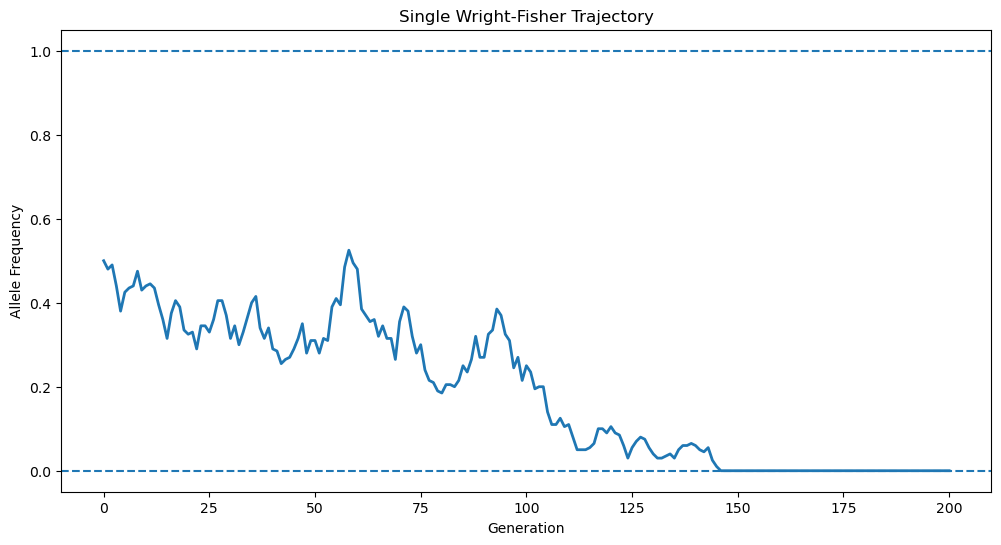

In [3]:

# Visualizing Drift


plt.figure(figsize=(12,6))

plt.plot(
    trajectory,
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel("Generation")
plt.ylabel("Allele Frequency")

plt.title(
    "Single Wright-Fisher Trajectory"
)

plt.ylim(
    -0.05,
    1.05
)

plt.show()



### Interpreting the Plot

Notice:

- Frequency fluctuates randomly
- No directional trend exists
- Changes occur despite no selection
- Eventually fixation or extinction may occur

This randomness is the hallmark of genetic drift.

### Simulating Multiple Populations

The true power of drift appears when we simulate many populations with identical starting conditions.

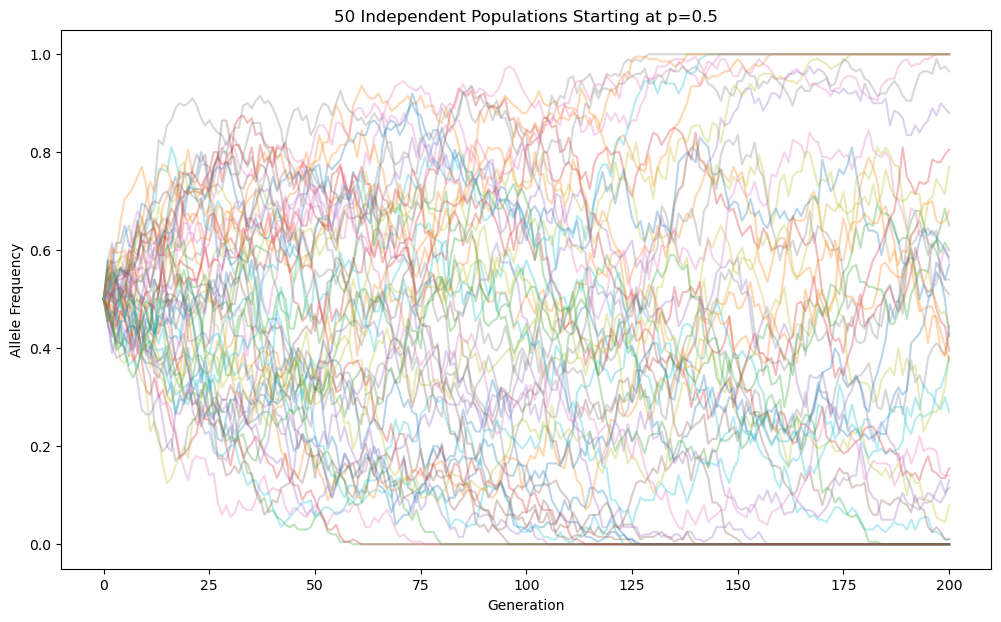

In [4]:

def simulate_many_populations(
    N=100,
    p0=0.5,
    generations=200,
    n_replicates=50
):

    trajectories=[]

    for _ in range(n_replicates):

        traj = simulate_drift(
            N,
            p0,
            generations
        )

        trajectories.append(traj)

    return np.array(trajectories)

trajectories = simulate_many_populations(
    N=100,
    p0=0.5,
    generations=200,
    n_replicates=50
)

plt.figure(figsize=(12,7))

for traj in trajectories:

    plt.plot(
        traj,
        alpha=0.3
    )

plt.xlabel("Generation")
plt.ylabel("Allele Frequency")

plt.title(
    "50 Independent Populations Starting at p=0.5"
)

plt.ylim(
    -0.05,
    1.05
)

plt.show()


### Interpretation

All populations began with: $p_0=0.5$. 

Yet they diverged dramatically.

Some populations moved upward.

Some moved downward.

Some approached fixation.

Some approached extinction.

This illustrates a central lesson:

> Evolutionary outcomes can differ substantially even when populations start under identical conditions.


### Summary

In this first part we learned:

- What genetic drift is
- Why finite populations matter
- What fixation means
- The Wright-Fisher model
- Classical theorems of drift
- Why small populations drift faster
- How to simulate allele-frequency trajectories

In Part 2 we will move beyond a single SNP and systematically investigate:

- Population size effects
- Initial allele frequency effects
- Fixation probability verification
- Multiple SNP simulations
- Sample size effects
- Allele frequency spectra

### Experimental Exploration of Genetic Drift

In Part 1, we simulated a single SNP evolving under neutral genetic drift.

Now we move toward a more realistic population genetics framework by asking:

- What happens when population size changes?
- What happens when initial allele frequency changes?
- Can we experimentally verify the fixation theorem?
- What happens when thousands of SNPs evolve simultaneously?
- How does sample size affect allele frequency estimates?
- How does drift reshape the allele frequency spectrum?

These experiments mirror questions encountered in modern statistical genetics and genomics.



### Experiment 1: Effect of Population Size

Recall the variance theorem:

$$
Var(p_{t+1}|p_t)
=
\frac{p_t(1-p_t)}{2N}
$$

The denominator contains population size:

$$
N
$$

Therefore:

- Small populations should drift rapidly.
- Large populations should drift slowly.

### Simulating Different Population Sizes

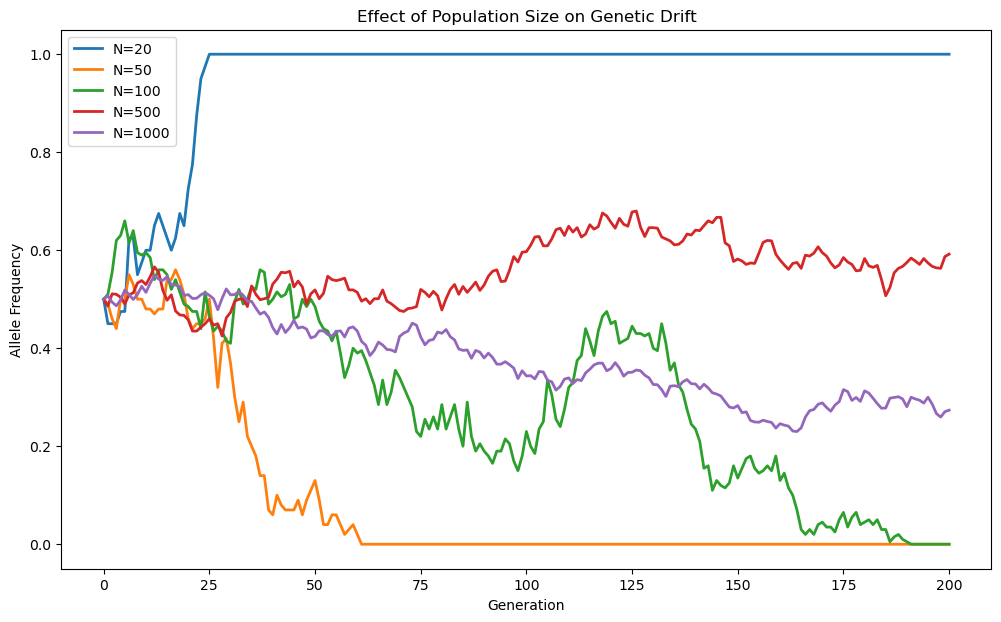

In [5]:

population_sizes = [
    20,
    50,
    100,
    500,
    1000
]

plt.figure(figsize=(12,7))

for N in population_sizes:

    traj = simulate_drift(
        N=N,
        p0=0.5,
        generations=200
    )

    plt.plot(
        traj,
        linewidth=2,
        label=f"N={N}"
    )

plt.xlabel("Generation")
plt.ylabel("Allele Frequency")

plt.title(
    "Effect of Population Size on Genetic Drift"
)

plt.legend()

plt.ylim(
    -0.05,
    1.05
)

plt.show()





### Interpretation

Notice the dramatic difference.

For:

$$
N=20
$$

the allele frequency may rapidly reach fixation or extinction.

For:

$$
N=1000
$$

the frequency remains close to its initial value.

This directly verifies the variance theorem.

### Quantifying Drift Variability

Instead of looking at one trajectory, we can measure variance across many replicate populations.

In [6]:
population_sizes = [
    20,
    50,
    100,
    500,
    1000
]

variances=[]

for N in population_sizes:

    final_freqs=[]

    for _ in range(1000):

        traj = simulate_drift(
            N=N,
            p0=0.5,
            generations=100
        )

        final_freqs.append(
            traj[-1]
        )

    variances.append(
        np.var(final_freqs)
    )


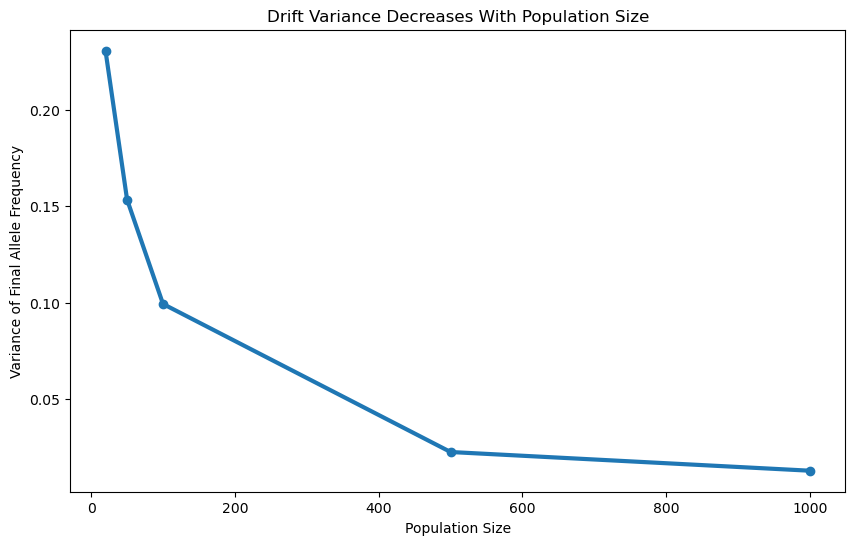

In [7]:
plt.figure(figsize=(10,6))

plt.plot(
    population_sizes,
    variances,
    marker="o",
    linewidth=3
)

plt.xlabel("Population Size")
plt.ylabel("Variance of Final Allele Frequency")

plt.title(
    "Drift Variance Decreases With Population Size"
)

plt.show()

### Experiment 2: Initial Allele Frequency

The fixation theorem states:

$$
P(Fixation)=p_0
$$

where, $p_0$ is the initial allele frequency.

We first visualize trajectories starting from different frequencies.

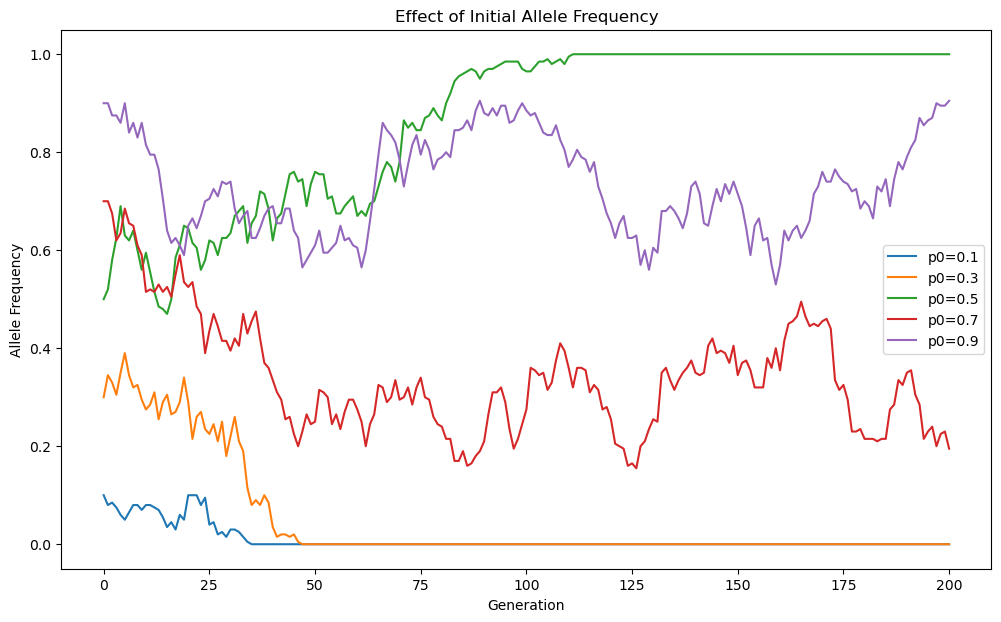

In [8]:
starting_frequencies = [
    0.1,
    0.3,
    0.5,
    0.7,
    0.9
]

plt.figure(figsize=(12,7))

for p0 in starting_frequencies:

    traj = simulate_drift(
        N=100,
        p0=p0,
        generations=200
    )

    plt.plot(
        traj,
        label=f"p0={p0}"
    )

plt.xlabel("Generation")
plt.ylabel("Allele Frequency")

plt.title(
    "Effect of Initial Allele Frequency"
)

plt.legend()

plt.show()



### Interpretation

Alleles beginning near $p=1$ have a much greater chance of fixation.

Alleles beginning near $p=0$

have a much greater chance of loss.

### Experiment 3: Verifying the Fixation Theorem

One of the most elegant results in population genetics states $P(Fixation)=p_0$ .

We now verify this experimentally.


In [9]:
def estimate_fixation_probability(
    p0,
    N=100,
    generations=1000,
    n_replicates=1000
):

    fixation_count=0

    for _ in range(n_replicates):

        traj = simulate_drift(
            N=N,
            p0=p0,
            generations=generations
        )

        if traj[-1] == 1:
            fixation_count += 1

    return fixation_count/n_replicates

p0_values = np.arange(
    0.05,
    1.0,
    0.05
)

estimated_probs=[]

for p0 in p0_values:

    estimated_probs.append(
        estimate_fixation_probability(
            p0=p0,
            N=100,
            generations=1000,
            n_replicates=500
        )
    )



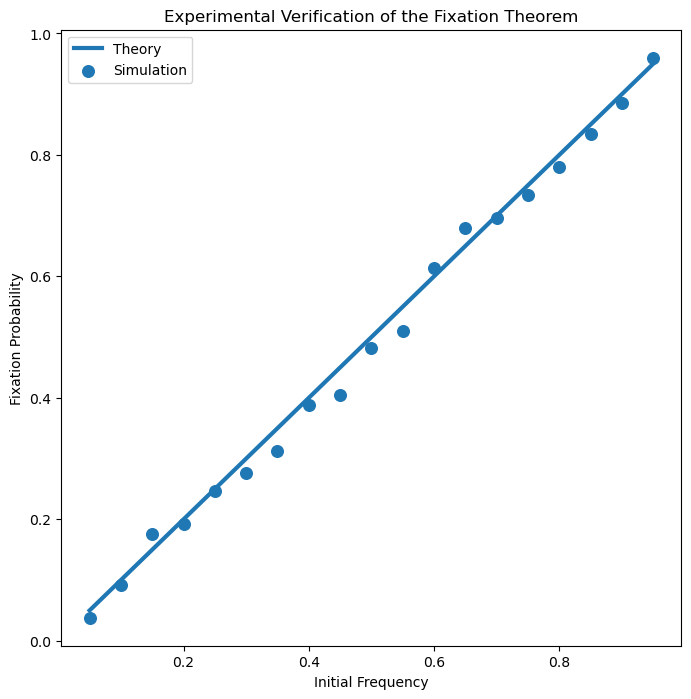

In [10]:
plt.figure(figsize=(8,8))

plt.plot(
    p0_values,
    p0_values,
    linewidth=3,
    label="Theory"
)

plt.scatter(
    p0_values,
    estimated_probs,
    s=70,
    label="Simulation"
)

plt.xlabel("Initial Frequency")
plt.ylabel("Fixation Probability")

plt.title(
    "Experimental Verification of the Fixation Theorem"
)

plt.legend()

plt.show()


### Interpretation

The simulation closely follows the theoretical prediction:

$$
P(Fixation)=p_0
$$

This is one of the most important theorems in neutral evolution.

### Experiment 4: Multiple SNP Simulation

Real genomes contain millions of SNPs.

Instead of tracking a single locus, we simulate many SNPs simultaneously.

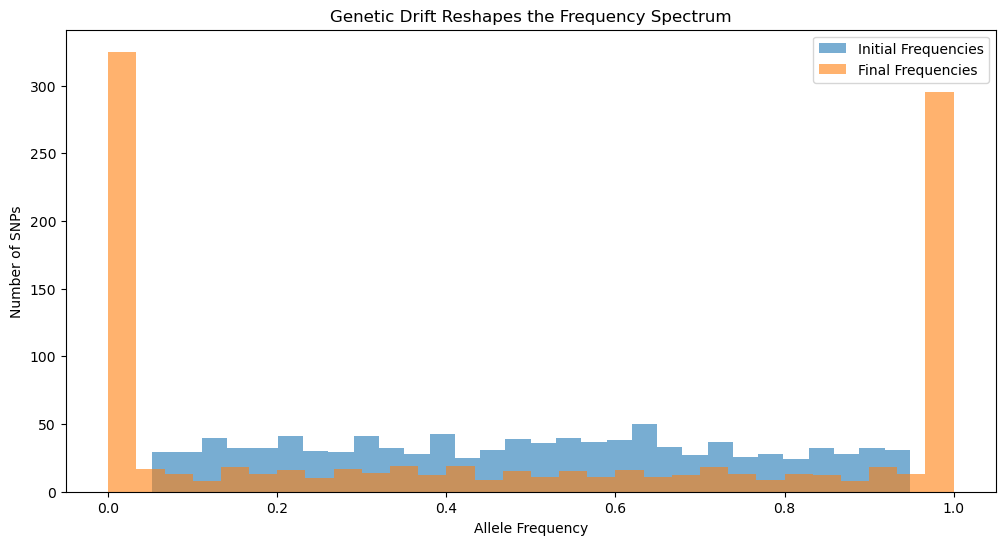

In [11]:
# Creating 1,000 Independent SNPs


n_snps = 1000

initial_freqs = np.random.uniform(
    0.05,
    0.95,
    n_snps
)

final_freqs=[]

for p0 in initial_freqs:

    traj = simulate_drift(
        N=100,
        p0=p0,
        generations=200
    )

    final_freqs.append(
        traj[-1]
    )


# Visualizing Frequency Changes

plt.figure(figsize=(12,6))

plt.hist(
    initial_freqs,
    bins=30,
    alpha=0.6,
    label="Initial Frequencies"
)

plt.hist(
    final_freqs,
    bins=30,
    alpha=0.6,
    label="Final Frequencies"
)

plt.xlabel("Allele Frequency")
plt.ylabel("Number of SNPs")

plt.title(
    "Genetic Drift Reshapes the Frequency Spectrum"
)

plt.legend()

plt.show()



### Interpretation

Initially, frequencies were nearly uniform.

After drift:

- More SNPs accumulate near 0
- More SNPs accumulate near 1
- Intermediate frequencies become less common

This is a hallmark of neutral evolution.

### Experiment 5: SNP Loss and Fixation

How many SNPs become fixed or lost?

Lost SNPs: 313
Fixed SNPs: 285


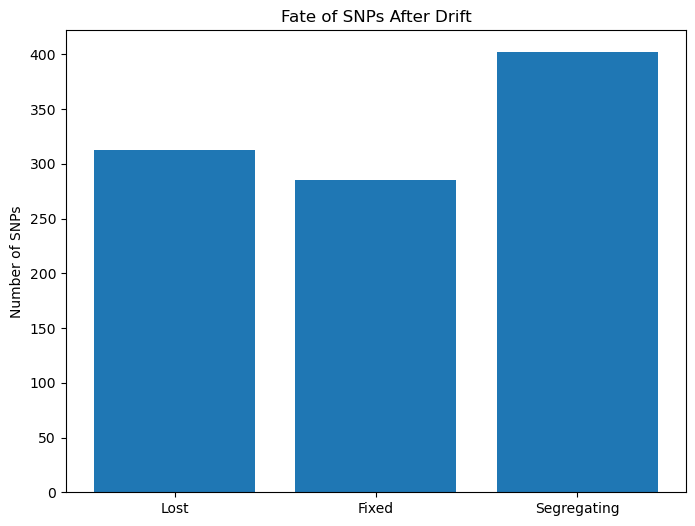

In [12]:


lost=0
fixed=0

for p in final_freqs:

    if p == 0:
        lost += 1

    elif p == 1:
        fixed += 1

print("Lost SNPs:", lost)
print("Fixed SNPs:", fixed)


# Visualization


categories = [
    "Lost",
    "Fixed",
    "Segregating"
]

counts = [
    lost,
    fixed,
    len(final_freqs)-lost-fixed
]

plt.figure(figsize=(8,6))

plt.bar(
    categories,
    counts
)

plt.ylabel("Number of SNPs")

plt.title(
    "Fate of SNPs After Drift"
)

plt.show()


### Experiment 6: Number of SNPs Matters

Now repeat the experiment using increasingly larger numbers of SNPs.


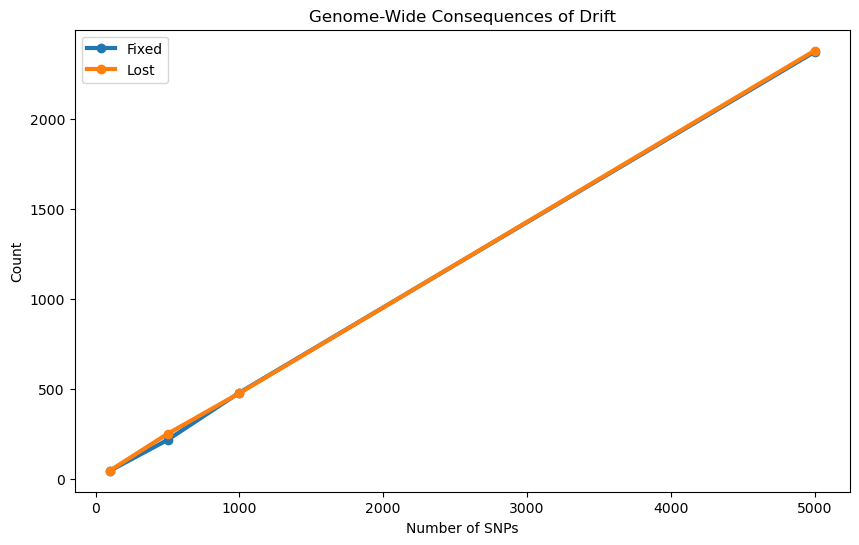

In [13]:

snp_counts = [
    100,
    500,
    1000,
    5000
]

fixed_counts=[]
lost_counts=[]

for n_snps in snp_counts:

    fixed=0
    lost=0

    freqs=np.random.uniform(
        0.05,
        0.95,
        n_snps
    )

    for p0 in freqs:

        traj=simulate_drift(
            N=50,
            p0=p0,
            generations=300
        )

        if traj[-1]==1:
            fixed += 1

        elif traj[-1]==0:
            lost += 1

    fixed_counts.append(fixed)
    lost_counts.append(lost)

plt.figure(figsize=(10,6))

plt.plot(
    snp_counts,
    fixed_counts,
    marker="o",
    linewidth=3,
    label="Fixed"
)

plt.plot(
    snp_counts,
    lost_counts,
    marker="o",
    linewidth=3,
    label="Lost"
)

plt.xlabel("Number of SNPs")
plt.ylabel("Count")

plt.title(
    "Genome-Wide Consequences of Drift"
)

plt.legend()

plt.show()




### Interpretation

As the number of SNPs increases:

- More variants become fixed
- More variants become lost
- Overall diversity declines

### Experiment 7: Sampling Error Versus Genetic Drift

In GWAS we rarely observe the entire population.

Instead we estimate allele frequencies from samples.

Suppose the true frequency is $p=0.30$.

### Simulating Sampling Error

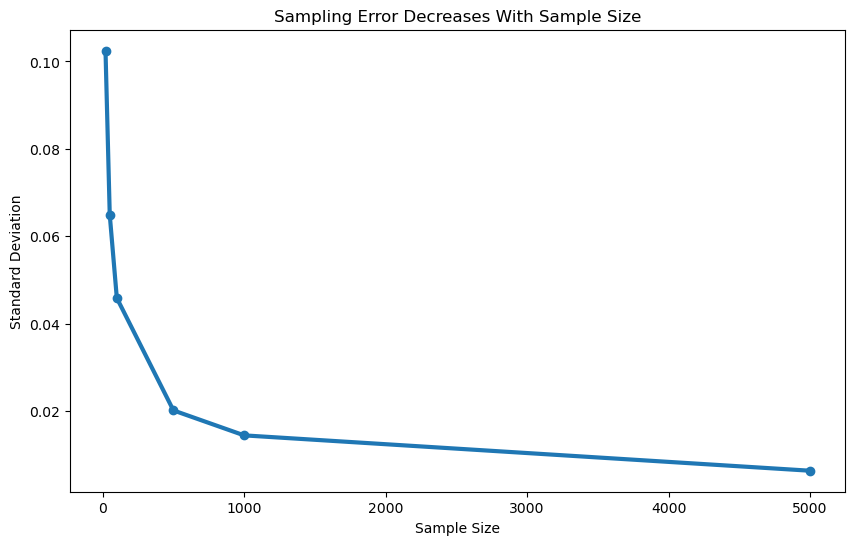

In [14]:

true_frequency = 0.30

sample_sizes = [
    20,
    50,
    100,
    500,
    1000,
    5000
]

sampling_std=[]

for n in sample_sizes:

    estimates=[]

    for _ in range(5000):

        count = np.random.binomial(
            n,
            true_frequency
        )

        estimates.append(
            count/n
        )

    sampling_std.append(
        np.std(estimates)
    )

plt.figure(figsize=(10,6))

plt.plot(
    sample_sizes,
    sampling_std,
    marker="o",
    linewidth=3
)

plt.xlabel("Sample Size")
plt.ylabel("Standard Deviation")

plt.title(
    "Sampling Error Decreases With Sample Size"
)

plt.show()





### Interpretation

Larger studies produce more precise allele frequency estimates.

This randomness is not genetic drift.

Instead it is statistical sampling error.

### Genetic Drift vs Sampling Error

| Genetic Drift | Sampling Error |
|--------------|---------------|
| Biological process | Measurement process |
| Occurs across generations | Occurs during data collection |
| Changes true frequency | Changes estimated frequency |
| Evolutionary phenomenon | Statistical phenomenon |

Understanding this distinction is essential in GWAS and population genetics.

### Experiment 8: Distribution of Frequency Estimates

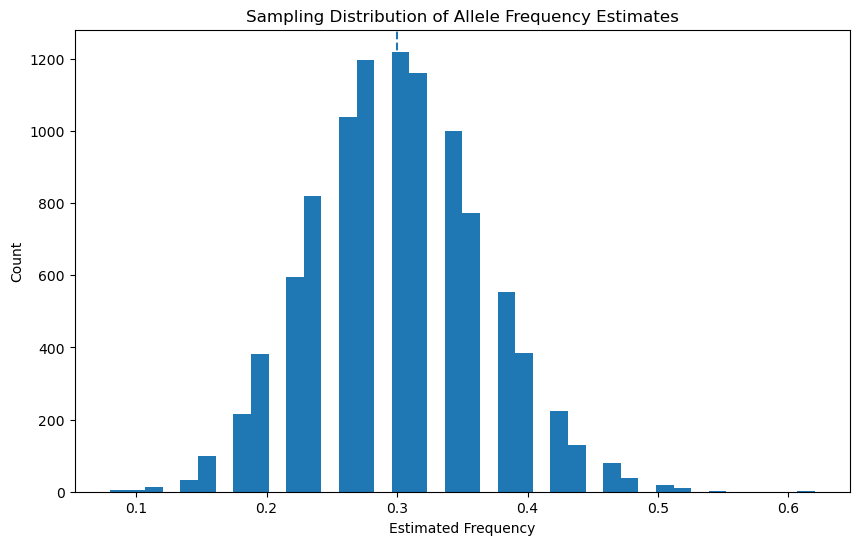

In [15]:

sample_size = 50

estimates=[]

for _ in range(10000):

    count=np.random.binomial(
        sample_size,
        true_frequency
    )

    estimates.append(
        count/sample_size
    )

plt.figure(figsize=(10,6))

plt.hist(
    estimates,
    bins=40
)

plt.axvline(
    true_frequency,
    linestyle="--"
)

plt.xlabel("Estimated Frequency")
plt.ylabel("Count")

plt.title(
    "Sampling Distribution of Allele Frequency Estimates"
)

plt.show()



### Interpretation

Even though the true frequency remains fixed at:

$$
p=0.30
$$

individual samples produce different estimates.

This is exactly why larger cohorts improve statistical power.

### Summary

In this section we experimentally demonstrated:

1. Small populations drift faster.
2. Large populations are more stable.
3. Fixation probability equals starting frequency.
4. Drift pushes SNPs toward fixation and extinction.
5. Diversity decreases across the genome.
6. Sample size affects precision of allele-frequency estimation.
7. Sampling error and genetic drift are fundamentally different processes.

In Part 3 we will move to:

- Genome-wide simulations
- Heterozygosity decay
- Effective population size
- Bottlenecks
- Founder effects
- Population structure
- GWAS implications
- Modern statistical genetics applications

### Genome-Wide Consequences of Genetic Drift

So far we have studied drift at the level of individual SNPs.

Real genomes contain millions of variants.

Over evolutionary time, drift acts simultaneously on all of them.

The cumulative effect produces:

- Loss of genetic diversity
- Population differentiation
- Founder effects
- Population bottlenecks
- Changes in allele frequency spectra

Many patterns observed in modern genomics can be understood through drift alone.

### Heterozygosity

One of the most important measures of genetic diversity is heterozygosity.

For a biallelic SNP:

$$
H = 2p(1-p)
$$

where:

- \(p\) = frequency of allele A
- \(1-p\) = frequency of allele a

### Maximum Heterozygosity

The maximum occurs when:

$$
p=0.5
$$

because:

$$
H=2(0.5)(0.5)=0.5
$$

The minimum occurs when:

$$
p=0
$$

or

$$
p=1
$$

because:

$$
H=0
$$

At fixation, all diversity disappears.

### Theoretical Decay of Heterozygosity

One of the classical results of population genetics is:

$$
H_t
=
H_0
\left(
1-\frac{1}{2N}
\right)^t
$$

where:

- \(H_0\) = initial heterozygosity
- \(N\) = population size
- \(t\) = generations

### Simulating Heterozygosity Decay


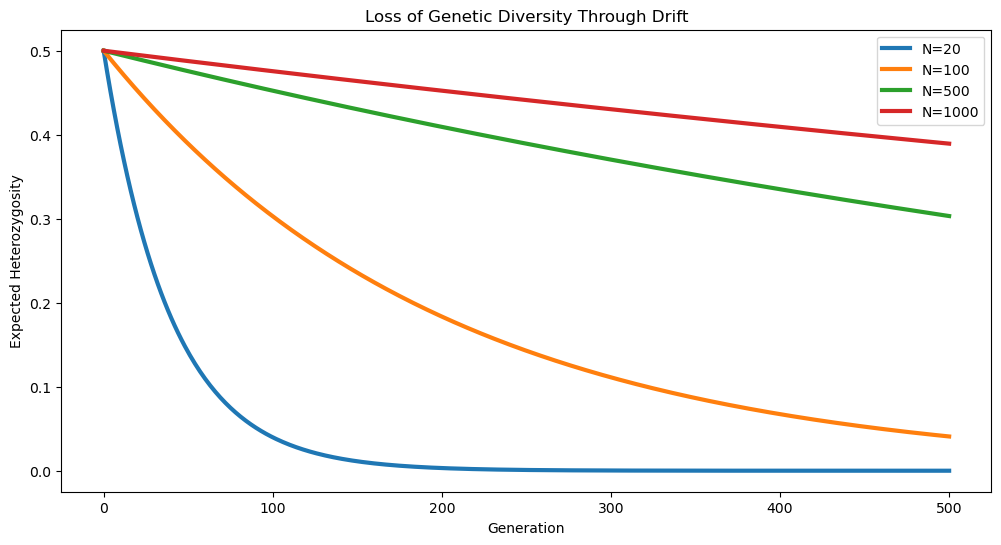

In [16]:

def heterozygosity_decay(
    H0,
    N,
    generations
):

    t = np.arange(
        generations+1
    )

    Ht = H0 * (
        1 - 1/(2*N)
    )**t

    return t, Ht

population_sizes = [
    20,
    100,
    500,
    1000
]

plt.figure(figsize=(12,6))

for N in population_sizes:

    t,Ht = heterozygosity_decay(
        H0=0.5,
        N=N,
        generations=500
    )

    plt.plot(
        t,
        Ht,
        linewidth=3,
        label=f"N={N}"
    )

plt.xlabel("Generation")
plt.ylabel("Expected Heterozygosity")

plt.title(
    "Loss of Genetic Diversity Through Drift"
)

plt.legend()

plt.show()




### Interpretation

Small populations lose diversity rapidly.

Large populations retain diversity for much longer periods.

This is one reason conservation biologists worry about endangered populations.

### Effective Population Size

A critical concept in population genetics is:

$$
N_e
$$

the effective population size.

#### Census Size vs Effective Size

Census size:

$$
N
$$

represents the number of individuals.

Effective population size:

$$
N_e
$$

represents the size of an ideal population that experiences the same amount of drift.

Usually:

$$
N_e < N
$$

### Why is Effective Population Size Smaller?

Real populations violate Wright-Fisher assumptions:

- Unequal family sizes
- Population structure
- Sex imbalance
- Bottlenecks
- Selection

All of these increase drift.

### Why Statistical Geneticists Care About Ne

Many quantities depend on:

$$
N_e
$$

including:

- LD decay
- Drift strength
- Coalescent times
- Polygenic adaptation
- Demographic inference

### Population Bottlenecks

A bottleneck occurs when population size suddenly decreases.

Examples include:

- Natural disasters
- Famine
- Disease outbreaks
- Founder migrations

### Bottleneck Simulation

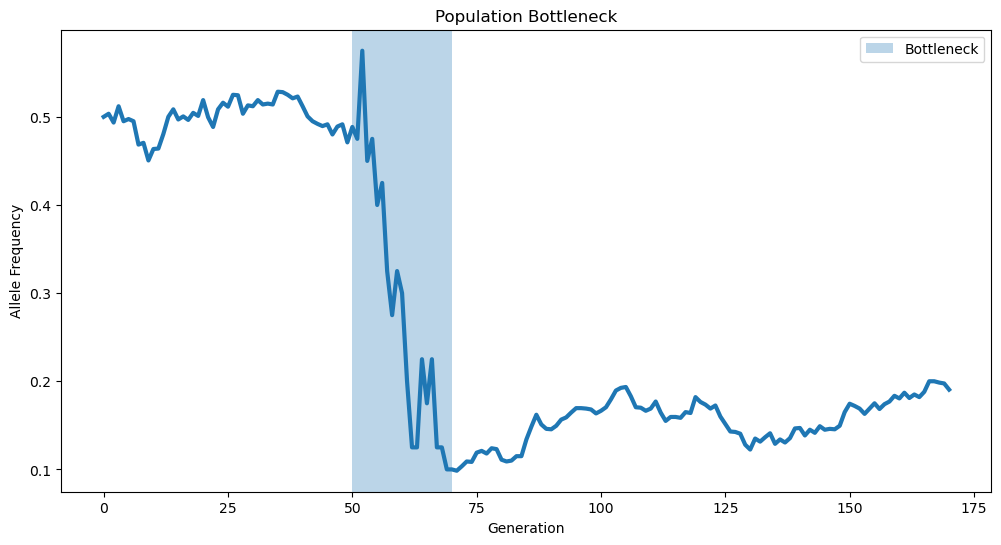

In [17]:

def simulate_bottleneck(
    p0=0.5,
    generations_before=50,
    generations_bottleneck=20,
    generations_after=100,
    N_before=1000,
    N_bottleneck=20,
    N_after=1000
):

    p = p0

    trajectory=[p]

    schedule = (
        [N_before]*generations_before +
        [N_bottleneck]*generations_bottleneck +
        [N_after]*generations_after
    )

    for N in schedule:

        count=np.random.binomial(
            2*N,
            p
        )

        p=count/(2*N)

        trajectory.append(p)

    return np.array(trajectory)

traj = simulate_bottleneck()

plt.figure(figsize=(12,6))

plt.plot(
    traj,
    linewidth=3
)

plt.axvspan(
    50,
    70,
    alpha=0.3,
    label="Bottleneck"
)

plt.xlabel("Generation")
plt.ylabel("Allele Frequency")

plt.title(
    "Population Bottleneck"
)

plt.legend()

plt.show()

### Interpretation

Most frequency changes occur during the bottleneck period.

This happens because:

$$
N
$$

temporarily becomes very small.

#### Founder Effects

A founder effect is a special case of drift.

A small group leaves a large population and establishes a new population.

The new population contains only a subset of the original genetic variation.

#### Founder Effect Simulation

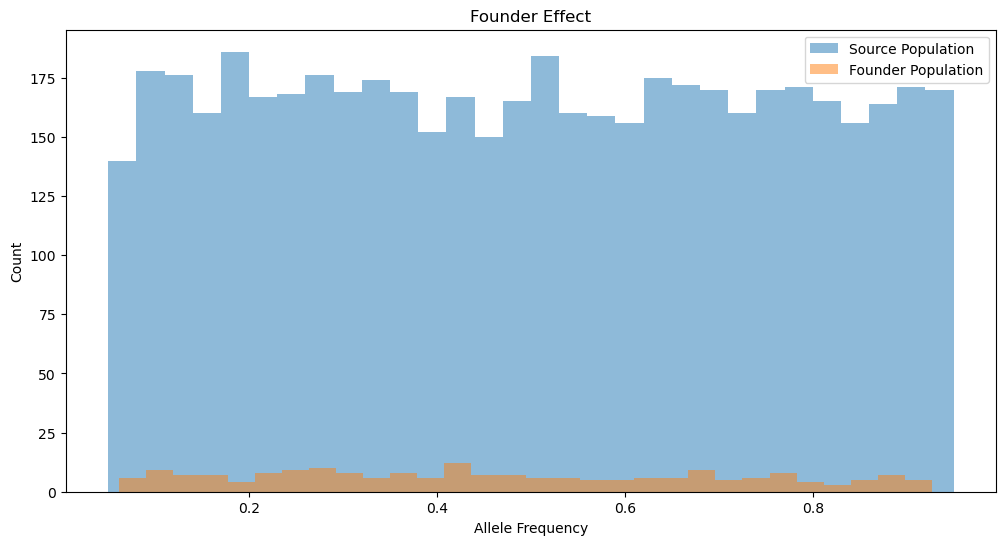

In [18]:

source_population = np.random.uniform(
    0.05,
    0.95,
    5000
)

founder_population = np.random.choice(
    source_population,
    size=200,
    replace=False
)

plt.figure(figsize=(12,6))

plt.hist(
    source_population,
    bins=30,
    alpha=0.5,
    label="Source Population"
)

plt.hist(
    founder_population,
    bins=30,
    alpha=0.5,
    label="Founder Population"
)

plt.xlabel("Allele Frequency")
plt.ylabel("Count")

plt.title(
    "Founder Effect"
)

plt.legend()

plt.show()



### Interpretation

Even before evolution occurs, the founder population already differs genetically.

This is purely due to sampling.

### Drift Across an Entire Genome

Now simulate:

- 10,000 SNPs
- 500 generations

Fixed: 4523
Lost: 4665
Segregating: 812


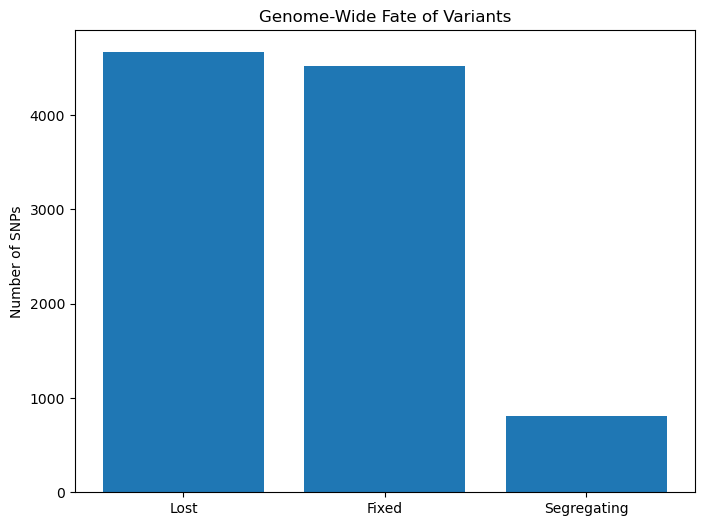

In [19]:

n_snps = 10000

initial_freqs = np.random.uniform(
    0.01,
    0.99,
    n_snps
)

final_freqs=[]

for p0 in initial_freqs:

    traj = simulate_drift(
        N=100,
        p0=p0,
        generations=500
    )

    final_freqs.append(
        traj[-1]
    )


# Fate of Variants


fixed = np.sum(
    np.array(final_freqs)==1
)

lost = np.sum(
    np.array(final_freqs)==0
)

segregating = (
    n_snps-fixed-lost
)

print("Fixed:", fixed)
print("Lost:", lost)
print("Segregating:", segregating)

plt.figure(figsize=(8,6))

plt.bar(
    ["Lost","Fixed","Segregating"],
    [lost,fixed,segregating]
)

plt.ylabel("Number of SNPs")

plt.title(
    "Genome-Wide Fate of Variants"
)

plt.show()




### Interpretation

After sufficient evolutionary time:

- Many variants disappear
- Many become fixed
- Only a subset remain polymorphic

### Genetic Drift and Population Structure

Different populations experience different drift histories.

Suppose two populations split.

Each evolves independently.

Their allele frequencies diverge over time.

### Simulating Divergence


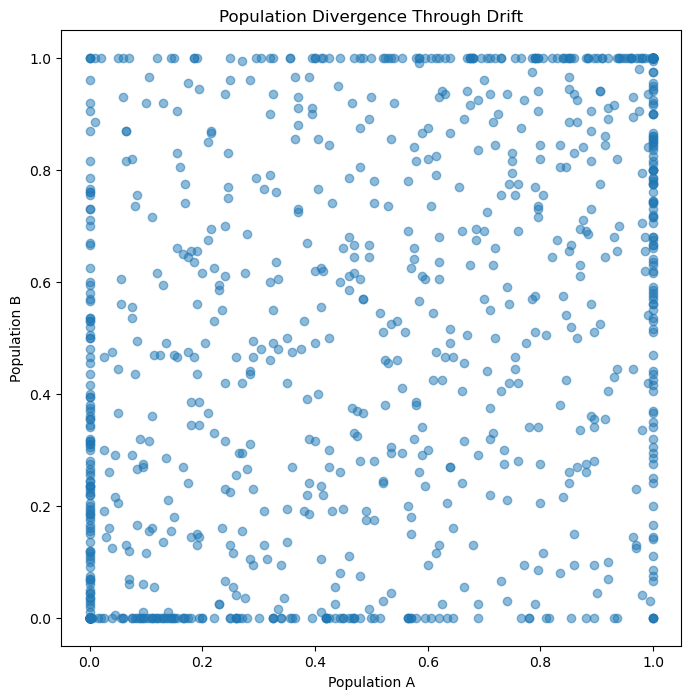

In [20]:

shared_freqs = np.random.uniform(
    0.05,
    0.95,
    1000
)

population_A=[]
population_B=[]

for p0 in shared_freqs:

    trajA = simulate_drift(
        N=100,
        p0=p0,
        generations=100
    )

    trajB = simulate_drift(
        N=100,
        p0=p0,
        generations=100
    )

    population_A.append(
        trajA[-1]
    )

    population_B.append(
        trajB[-1]
    )

plt.figure(figsize=(8,8))

plt.scatter(
    population_A,
    population_B,
    alpha=0.5
)

plt.xlabel("Population A")
plt.ylabel("Population B")

plt.title(
    "Population Divergence Through Drift"
)

plt.show()






### Interpretation

The populations began identically.

Drift alone created differences.

This is the foundation of population structure.

### Connection to FST

Population differentiation is often measured using:

$$
F_{ST}
$$

which quantifies how much allele frequencies differ between populations.

Drift increases:

$$
F_{ST}
$$

over time.

### Why GWAS Researchers Care About Drift

Modern GWAS datasets contain individuals from populations with different demographic histories.

Drift can create allele-frequency differences unrelated to disease.

#### Example

Suppose:

Population A:

$$
p=0.7
$$

Population B:

$$
p=0.3
$$

for a SNP.

If disease prevalence also differs between populations, a naive GWAS may falsely associate the SNP with disease.

#### Confounding

This phenomenon is called:

Population stratification.

Drift is one of its major causes.

### How GWAS Controls Drift Effects

Modern studies use:

- Principal Components Analysis (PCA)
- Linear Mixed Models
- Genetic Relationship Matrices
- Ancestry Adjustment

to account for population structure.

### Connection to FinnGen

Finnish populations experienced:

- Founder events
- Bottlenecks
- Relative isolation

Consequently:

- Some rare variants became common
- Certain disease alleles increased in frequency

This is known as the Finnish Disease Heritage.

### Connection to UK Biobank

UK Biobank contains:

- Multiple ancestry groups
- Geographic structure
- Historical demographic differences

These produce subtle allele-frequency differences caused partly by drift.

### Connection to Polygenic Scores

Polygenic scores depend on allele frequencies.

Since drift changes frequencies:

- Prediction accuracy changes across populations
- Transferability decreases
- Ancestry matching becomes important





1. Genetic drift is random evolution caused by finite populations.

2. Drift eventually causes fixation or extinction.

3. Small populations drift faster than large populations.

4. Heterozygosity decreases through time.

5. Effective population size determines drift strength.

6. Bottlenecks accelerate drift.

7. Founder effects reshape genetic variation.

8. Drift creates population structure.

9. Drift contributes to FST.

10. Drift influences GWAS, polygenic scores, and demographic inference.


### Summary

One of the most surprising lessons in population genetics is that evolution does not always require selection.

Randomness alone can dramatically reshape genomes.

Given enough time, drift can:

- Eliminate variants
- Fix variants
- Reduce diversity
- Differentiate populations

Many genomic patterns observed today arise not because some variants were better than others, but simply because finite populations are subject to chance.

Understanding genetic drift is therefore essential for evolutionary biology, statistical genetics, genomics, and modern precision medicine.